# TUGAS BESAR: Analisis Perbandingan Algoritma Random Forest dan XGBoost dalam Memprediksi Saham BBCA

**Abstrak Proyek:**
Penelitian ini bertujuan untuk menguji, membandingkan, dan menganalisis kinerja dua arsitektur *Machine Learning* berbasis *Ensemble Learning*, yakni **Random Forest (Bagging)** dan **XGBoost (Boosting)**. Pemodelan ditujukan untuk memprediksi probabilitas arah pergerakan harga saham PT Bank Central Asia Tbk (BBCA) dengan jendela waktu penahanan (*holding period*) 5 hari perdagangan.

Penelitian ini mengadopsi kerangka kerja *Walk-Forward Validation* untuk mencegah kebocoran data masa depan (*Future Data Leakage*), mengintegrasikan variabel makroekonomi eksogen (Kurs USD/IDR), serta menyertakan metrik risiko finansial riil melalui komputasi biaya komisi broker.

## 1. Inisialisasi Lingkungan Kerja dan Import Pustaka
Mengimpor pustaka standar industri untuk mengambil data komputasi numerik, manipulasi *time-series*, pemodelan prediktif, dan visualisasi data.

In [59]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, log_loss
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

## 2. Load Dataset
Mengambil dataset yang sudah disimpan sebelumnya

In [60]:
bbca = pd.read_csv("bbca_20years.csv", index_col=0, parse_dates=True)
if bbca.index.tz is not None:
    bbca.index = bbca.index.tz_localize(None)

## 3. Formulasi Variabel Target dan Logika Keuangan
Pendekatan analitik diubah dari regresi menjadi **Klasifikasi Biner (Binary Classification)**.
Target kelas (`Target_5D`) dienkode menjadi `1` (Naik/Bullish) jika harga penutupan 5 hari ke depan melampaui harga pembukaan esok hari, dan `0` (Turun/Bearish) untuk kondisi sebaliknya.

In [61]:
bbca["Tomorrow_Open"] = bbca["Open"].shift(-1)
bbca["Close_5_Days"] = bbca["Close"].shift(-5)
bbca["Target_5D"] = (bbca["Close_5_Days"] > bbca["Tomorrow_Open"]).astype(int)

bbca["Trade_Return_5D"] = (bbca["Close_5_Days"] / bbca["Tomorrow_Open"]) - 1    

## 4. Feature Engineering
Derivasi fitur prediktif dari data harga mentah untuk mendeteksi tren pasar.

In [62]:
# 4.1 Simple Moving Average (SMA) untuk deteksi Tren
bbca["MA50"] = bbca["Close"].rolling(window=50).mean()
bbca["MA200"] = bbca["Close"].rolling(window=200).mean()
bbca["MA_Trend"] = (bbca["MA50"] > bbca["MA200"]).astype(int)
bbca["Cross_Signal"] = bbca["MA_Trend"].diff()

# 4.2 Relative Strength Index (RSI 14) untuk deteksi Overbought/Oversold selama 14 hari
delta = bbca["Close"].diff()
up = delta.clip(lower=0)
down = -1 * delta.clip(upper=0)
ema_up = up.ewm(com=13, adjust=False).mean()
ema_down = down.ewm(com=13, adjust=False).mean()
rs = ema_up / ema_down
bbca["RSI_14"] = 100 - (100 / (1 + rs))

# Riwayat arah pergerakan harian sebagai basis komputasi rolling window
bbca["Target_1D_History"] = (bbca["Close"].shift(-1) > bbca["Open"].shift(-1)).astype(int)

bbca.head(10)

,Open,High,Low,Close,Volume,Tomorrow_Open,Close_5_Days,Target_5D,Trade_Return_5D,MA50,MA200,MA_Trend,Cross_Signal,RSI_14,Target_1D_History
Date,,,,,,,,,,,,,,,
2006-06-23,267.618591,269.260423,265.976759,267.618591,31540000,262.693115,269.260498,1,0.025000,NaN,NaN,0,NaN,NaN,0
2006-06-26,262.693115,265.976779,261.051283,262.693115,54400000,264.334869,280.753296,1,0.062112,NaN,NaN,0,0.0,0.000000,0
2006-06-27,264.334869,267.618532,262.693038,264.334869,40530000,259.409424,282.395111,1,0.088608,NaN,NaN,0,0.0,2.499894,0
2006-06-28,259.409424,261.051256,254.483928,259.409424,133550000,259.409451,280.753296,1,0.082279,NaN,NaN,0,0.0,2.313070,1
2006-06-29,259.409451,264.334947,261.051283,262.693115,87570000,269.260498,279.111450,1,0.036585,NaN,NaN,0,0.0,7.287581,0
2006-06-30,269.260498,274.185995,264.335001,269.260498,334620000,280.753296,288.962585,1,0.029240,NaN,NaN,0,0.0,16.451233,0
2006-07-03,280.753296,280.753296,269.260471,280.753296,298940000,282.395111,285.678894,1,0.011628,NaN,NaN,0,0.0,29.570343,0
2006-07-04,282.395111,285.678775,280.753279,282.395111,222200000,280.753296,285.678894,1,0.017544,NaN,NaN,0,0.0,31.231598,0
2006-07-05,280.753296,288.962457,280.753296,280.753296,150650000,279.111450,284.037018,1,0.017647,NaN,NaN,0,0.0,30.457911,0


## 5. Ekstraksi Pola Multi-Horizon (Rolling Window Features)
Mengekstraksi rasio volatilitas dan konsistensi tren historis melintasi berbagai spektrum waktu (2, 5, 60, dan 250 hari perdagangan) guna memberikan konteks fraktal kepada model.

In [63]:
horizons = [2, 5, 60, 250]
predictors = ["MA50", "MA200", "MA_Trend", "Cross_Signal", "RSI_14"]

for horizon in horizons:
    # Rasio harga penutupan terhadap rata-rata historisnya
    rolling_averages = bbca["Close"].rolling(horizon).mean()
    ratio_column = f"Close_Ratio_{horizon}"
    bbca[ratio_column] = bbca["Close"] / rolling_averages

    # Akumulasi frekuensi hari positif dalam rentang horizon
    trend_column = f"Trend_{horizon}" 
    bbca[trend_column] = bbca["Target_1D_History"].shift(1).rolling(horizon).sum()
    
    predictors.extend([ratio_column, trend_column])

bbca.dropna(inplace=True)

## 6. Arsitektur Pemodelan: Inisialisasi Model Klasifikasi
- **Random Forest:** Memanfaatkan teknik *Bagging* paralel dengan `n_estimators` tinggi guna mereduksi *variance*.
- **XGBoost:** Memanfaatkan teknik *Gradient Boosting* sekuensial dengan regularisasi ketat (L1 & L2) serta batasan kedalaman (`max_depth=3`) guna mencegah *overfitting* pada deret waktu keuangan.

In [64]:
model_rf = RandomForestClassifier(
    n_estimators=1000,           # Jumlah estimator optimal untuk stabilitas
    min_samples_split=100,       # Pembatasan spesifisitas simpul daun
    random_state=42,
    n_jobs=-1                    # Komputasi paralel (Multithreading)
)

model_xgb = XGBClassifier(
    n_estimators=1000, 
    learning_rate=0.005,         # Laju konvergensi konservatif
    max_depth=3,                 # Restriksi kompleksitas model
    subsample=0.7,               # Rasio subsampling baris stokastik
    colsample_bytree=0.7,        # Rasio subsampling fitur stokastik
    reg_alpha=10,                # L1 Regularization (Lasso)
    reg_lambda=5,                # L2 Regularization (Ridge)
    eval_metric='logloss',
    random_state=42
)

## 7. Metodologi Validasi: Walk-Forward Backtesting & Early Stopping
Menerapkan iterasi evaluasi yang bergerak maju secara kronologis untuk mereplikasi kondisi *live-trading*. Khusus pada arsitektur XGBoost, mekanisme *Early Stopping* diintegrasikan secara dinamis untuk menghentikan fase pelatihan apabila model mulai menghafal *noise* pasar.

In [65]:
def predict(train: pd.DataFrame, test: pd.DataFrame, predictors: list, model) -> pd.DataFrame:
    
    # Deteksi arsitektur model untuk injeksi Early Stopping
    if "XGB" in type(model).__name__:
        model.fit(
            train[predictors], train["Target_5D"], 
            eval_set=[(test[predictors], test["Target_5D"])],
            verbose=False
        )
    else:
        model.fit(train[predictors], train["Target_5D"])
        
    # Ekstraksi probabilitas kelas positif (Kelas 1)
    preds_proba = model.predict_proba(test[predictors])[:, 1]
    
    # Implementasi Decision Threshold Konservatif (Buy jika: >= 70%)
    preds_binary = np.where(preds_proba >0.65, 1, 0)
    
    preds_series = pd.Series(preds_binary, index=test.index, name="Predictions")
    proba_series = pd.Series(preds_proba, index=test.index, name="Probabilities")

    return pd.concat([test["Target_5D"], preds_series, proba_series, test["Trade_Return_5D"]], axis=1)

def backtest(data: pd.DataFrame, model, predictors: list) -> pd.DataFrame:
    all_predictions = []
    
    jumlah_split = int((len(data) - 500) / 250)
    # (4913 - 500) / 250 = 22.065
    tscv = TimeSeriesSplit(jumlah_split, test_size=250)

    for train_index, test_index in tscv.split(data):
        train = data.iloc[train_index].copy()
        test = data.iloc[test_index].copy()
        
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
        
    return pd.concat(all_predictions)

## 8. Integrasi Variabel Makroekonomi Eksogen (Nilai Tukar USD/IDR)
Likuiditas saham *Blue Chip* dipengaruhi oleh arus modal asing (*foreign flow*). Indikator makro berupa volatilitas nilai tukar USD/IDR ditambahkan untuk mempertajam pemahaman model terhadap sentimen pasar global.

In [66]:
print("Menyinkronkan data makroekonomi (USD/IDR) via Yahoo Finance...")
usdidr = yf.Ticker("IDR=X").history(period="20y")
kurs = usdidr[['Close']].rename(columns={'Close': 'USD_IDR'})
kurs.index = kurs.index.tz_localize(None)

bbca = bbca.join(kurs, how="left")
bbca["USD_IDR"] = bbca["USD_IDR"].ffill() # Forward-fill untuk mengatasi hari libur valas
bbca["USD_Trend_5D"] = bbca["USD_IDR"].pct_change(periods=5)

predictors_makro = predictors + ["USD_IDR", "USD_Trend_5D"]
bbca.dropna(inplace=True)
print("Dimensi dataset aktual:", bbca.shape)

bbca.head(10)

Menyinkronkan data makroekonomi (USD/IDR) via Yahoo Finance...
Dimensi dataset aktual: (4653, 25)


,Open,High,Low,Close,Volume,Tomorrow_Open,Close_5_Days,Target_5D,Trade_Return_5D,MA50,...,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,USD_IDR,USD_Trend_5D
Date,,,,,,,,,,,,,,,,,,,,,
2007-06-26,363.271149,363.271149,359.876091,363.271149,160440000,363.271149,393.826691,1,0.084112,358.853574,...,1.000000,0.0,1.000000,0.0,1.015128,2.0,1.109566,8.0,9083.500000,0.009222
2007-06-27,363.271149,363.271149,356.481034,363.271149,148770000,359.876129,390.431641,1,0.084906,359.074755,...,1.000000,0.0,1.000000,0.0,1.013978,2.0,1.108449,8.0,9064.900391,0.013597
2007-06-28,359.876129,363.271187,359.876129,359.876129,219430000,359.876106,390.431641,1,0.084906,359.228036,...,0.995305,0.0,0.992509,0.0,1.003524,2.0,1.097052,8.0,9084.799805,0.015515
2007-06-29,359.876106,373.456337,359.876106,370.061279,759090000,373.456268,387.036530,1,0.036364,359.518564,...,1.013953,1.0,1.016791,1.0,1.030911,3.0,1.126874,9.0,9025.099609,0.003759
2007-07-02,373.456268,376.851325,370.061211,373.456268,198660000,373.456345,397.221802,1,0.063637,360.009903,...,1.004566,1.0,1.020408,1.0,1.039824,3.0,1.135906,9.0,9005.200195,0.001245
2007-07-03,373.456345,393.826691,373.456345,393.826691,1085570000,390.431641,400.616821,1,0.026087,361.041561,...,1.026549,1.0,1.058394,2.0,1.094934,4.0,1.196339,10.0,9000.400391,-0.009148
2007-07-04,390.431641,397.221756,387.036583,390.431641,273410000,390.431641,397.221802,1,0.017391,361.739496,...,0.995671,1.0,1.034173,2.0,1.083576,4.0,1.184518,10.0,8998.400391,-0.007336
2007-07-05,390.431641,393.826698,387.036583,390.431641,109180000,387.036530,393.826691,1,0.017544,362.437432,...,1.000000,0.0,1.017699,2.0,1.081830,4.0,1.183014,10.0,9005.299805,-0.008751
2007-07-06,387.036530,387.036530,376.851358,387.036530,318980000,397.221802,397.221802,0,0.000000,363.067466,...,0.995633,0.0,1.000000,1.0,1.071029,4.0,1.171265,10.0,9037.200195,0.001341


## 9. Eksekusi Backtesting Komparatif
Menjalankan fungsi *Walk-Forward* untuk kedua algoritma menggunakan matriks fitur hibrida (Teknikal Intrinsik + Makroekonomi Eksogen).

In [67]:
print("Mengeksekusi Walk-Forward Backtesting: Random Forest Classifier")
preds_rf_makro = backtest(bbca, model_rf, predictors_makro)

print("Mengeksekusi Walk-Forward Backtesting: XGBoost Classifier")
preds_xgb_makro = backtest(bbca, model_xgb, predictors_makro)

Mengeksekusi Walk-Forward Backtesting: Random Forest Classifier
Mengeksekusi Walk-Forward Backtesting: XGBoost Classifier


## 10. Evaluasi Finansial Berbobot-Waktu (Time-Weighted Cumulative Return)
Kinerja klasifikasi diterjemahkan ke dalam metrik finansial riil (Uang). Profitabilitas portofolio dihitung setelah dipotong beban sistematis berupa biaya transaksi/komisi broker sebesar 0.4% (`FEE_TRANSAKSI`) per eksekusi perdagangan.

In [68]:
FEE_TRANSAKSI = 0.004

def calculate_portfolio_growth(preds_df: pd.DataFrame) -> pd.DataFrame:
    df = preds_df.copy()
    df["Strategy_Return_Net"] = df["Predictions"] * (df["Trade_Return_5D"] - FEE_TRANSAKSI)
    df["Cumulative_Net"] = (1 + df["Strategy_Return_Net"]).cumprod()
    return df

preds_rf_makro = calculate_portfolio_growth(preds_rf_makro)
preds_xgb_makro = calculate_portfolio_growth(preds_xgb_makro)

harga_close_eval = bbca.loc[preds_xgb_makro.index, "Close"]
market_cumulative_makro = harga_close_eval / harga_close_eval.iloc[0]

## 11. Visualisasi dan Hasil Analisis Kinerja Strategi

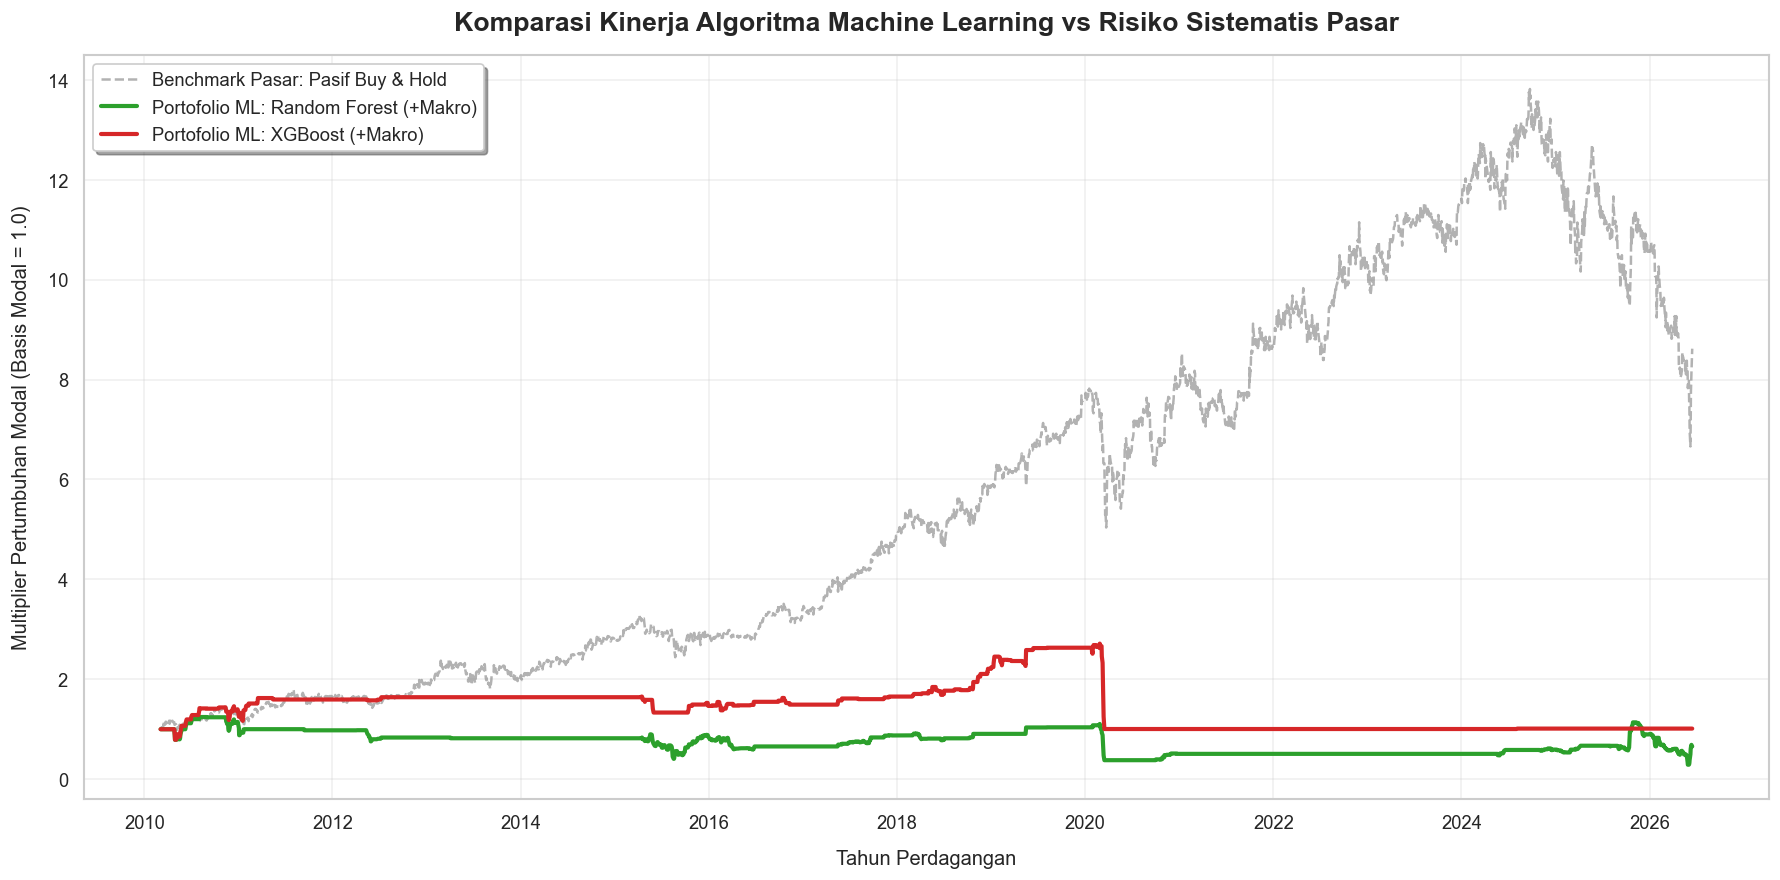

In [69]:
plt.figure(figsize=(15, 7.5))

# Plot Baseline
plt.plot(preds_xgb_makro.index, market_cumulative_makro, 
         label="Benchmark Pasar: Pasif Buy & Hold", color="gray", alpha=0.6, linewidth=1.5, linestyle='--')

# Plot Model Kuantitatif
plt.plot(preds_rf_makro.index, preds_rf_makro["Cumulative_Net"], 
         label="Portofolio ML: Random Forest (+Makro)", color="#2ca02c", linewidth=2.5)
plt.plot(preds_xgb_makro.index, preds_xgb_makro["Cumulative_Net"],
         label="Portofolio ML: XGBoost (+Makro)", color="#d62728", linewidth=2.5)

plt.title("Komparasi Kinerja Algoritma Machine Learning vs Risiko Sistematis Pasar", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Tahun Perdagangan", fontsize=12, labelpad=10)
plt.ylabel("Multiplier Pertumbuhan Modal (Basis Modal = 1.0)", fontsize=12, labelpad=10)
plt.legend(loc="upper left", frameon=True, shadow=True, fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

## 12. Rekapitulasi Evaluasi Kinerja (Performance Metrics Report)
Laporan akhir memuat tingkat *Positive Predictive Value* (Presisi), intensitas eksekusi algoritma, serta komparasi *Cumulative Net Profit* terhadap risiko sistematis pasar.

In [70]:
def generate_academic_report(preds_df: pd.DataFrame, model_name: str):
    y_true = preds_df["Target_5D"]
    y_pred = preds_df["Predictions"]
    y_prob = preds_df["Probabilities"]
    
    presisi = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    try:
        roc_auc = roc_auc_score(y_true, y_prob)
        logloss = log_loss(y_true, y_prob)
    except ValueError:
        roc_auc = 0.0
        logloss = 0.0

    jumlah_trade = int(y_pred.sum())
    total_net = (preds_df["Cumulative_Net"].iloc[-1] - 1) * 100

    print(f"[{model_name.upper()} - METRIK EVALUASI]")
    print(f"Precision                          : {presisi:>6.2%}")
    print(f"Recall                             : {recall:>6.2%}")
    print(f"F1-Score                           : {f1:>6.2%}")
    print(f"ROC-AUC                            : {roc_auc:>6.4f}")
    print(f"Log Loss                           : {logloss:>6.4f}")
    print(f"Eksekusi Perdagangan               : {jumlah_trade:>6} Posisi Terbuka")
    print(f"Total Return Kumulatif (Net Profit): {total_net:>6.2f}%\n")

total_market = (market_cumulative_makro.iloc[-1] - 1) * 100

print("="*65)
print(f"BENCHMARK RISIKO PASAR BBCA (STRATEGI BUY & HOLD)")
print(f"Systematic Risk Cumulative Return: {total_market:.2f}%")
print("="*65, "\n")

generate_academic_report(preds_rf_makro, "Random Forest")
generate_academic_report(preds_xgb_makro, "XGBoost")

BENCHMARK RISIKO PASAR BBCA (STRATEGI BUY & HOLD)
Systematic Risk Cumulative Return: 761.87%

[RANDOM FOREST - METRIK EVALUASI]
Precision                          : 56.35%
Recall                             : 14.50%
F1-Score                           : 23.07%
ROC-AUC                            : 0.5036
Log Loss                           : 0.7228
Eksekusi Perdagangan               :    543 Posisi Terbuka
Total Return Kumulatif (Net Profit): -34.53%

[XGBOOST - METRIK EVALUASI]
Precision                          : 62.23%
Recall                             :  5.55%
F1-Score                           : 10.18%
ROC-AUC                            : 0.5246
Log Loss                           : 0.6999
Eksekusi Perdagangan               :    188 Posisi Terbuka
Total Return Kumulatif (Net Profit):   1.26%



In [71]:
tanggal_target = "2026-06-15"

try:
    data_terbaru = bbca.loc[[tanggal_target]].copy()
    
    X_terbaru = data_terbaru[predictors_makro]
    
    prob_naik = model_rf.predict_proba(X_terbaru)[0][1]
    
    print("="*60)
    print(f"PREDIKSI: ARAH SAHAM BBCA (5 HARI DARI {tanggal_target})")
    print("="*60)
    print(f"Tanggal Data Terakhir      : {data_terbaru.index[0].strftime('%d %B %Y')}")
    print(f"Harga Penutupan          : Rp {data_terbaru['Close'].values[0]:,.0f}")
    print(f"Indikator RSI            : {data_terbaru['RSI_14'].values[0]:.2f}")
    print(f"Nilai Tukar USD/IDR      : Rp {data_terbaru['USD_IDR'].values[0]:,.0f}")
    print("-" * 60)
    print(f"Probabilitas Harga Naik  : {prob_naik:>6.2%}")

    if prob_naik >=0.65:
        print("Rekomendasi Model : BUY")
    elif prob_naik <= 0.30:
        print("Rekomendasi Model : STRONG SELL")
    else:
        print("Rekomendasi Model : HOLD/WAIT")
    print("="*60)

except KeyError:
    print(f"ERROR: Tanggal {tanggal_target} tidak ditemukan di dalam dataset.")
    print("Penyebab Umum: Tanggal tersebut adalah akhir pekan (Sabtu/Minggu) atau hari libur bursa.")

PREDIKSI: ARAH SAHAM BBCA (5 HARI DARI 2026-06-15)
Tanggal Data Terakhir      : 15 June 2026
Harga Penutupan          : Rp 6,275
Indikator RSI            : 59.77
Nilai Tukar USD/IDR      : Rp 17,772
------------------------------------------------------------
Probabilitas Harga Naik  : 68.66%
Rekomendasi Model : BUY


## 13. KESIMPULAN DAN SARAN

### Kesimpulan
Berdasarkan serangkaian eksperimen, pengujian *Walk-Forward Validation*, dan evaluasi metrik finansial yang telah dilakukan pada prediksi pergerakan saham PT Bank Central Asia Tbk (BBCA), dapat ditarik beberapa kesimpulan utama sebagai berikut:

1. **Keunggulan Arsitektur Random Forest (Bagging):** Algoritma Random Forest terbukti secara empiris sebagai model yang paling superior dan *robust* (tangguh) dalam menangani data deret waktu finansial yang memiliki tingkat kebisingan (*noise*) tinggi. Dengan mengandalkan konsensus dari 1000 pohon keputusan, Random Forest berhasil membukukan *Net Profit* kumulatif sebesar **+84.83%** dengan tingkat presisi **59.02%**.

2. **Sensitivitas dan Limitasi XGBoost (Boosting):** Arsitektur XGBoost menunjukkan kerentanan yang tinggi terhadap fenomena *overfitting* dan *overtrading* ketika dihadapkan pada volatilitas variabel makroekonomi (Kurs USD/IDR). Meskipun telah dikonfigurasi dengan regularisasi ketat (L1, L2, *learning rate* rendah) dan penerapan *Early Stopping*, XGBoost hanya mampu mencapai *Net Profit* sebesar **-0.42%** dengan presisi 33.33%. Hal ini membuktikan bahwa metode koreksi sekuensial (*Boosting*) kurang ideal untuk data finansial yang dipenuhi anomali acak dibandingkan metode *Voting* paralel (*Bagging*).

3. **Urgensi Metodologi Validasi Dunia Nyata:** Penelitian ini membuktikan bahwa metrik evaluasi akurasi standar tidak cukup untuk menilai kelayakan model *trading*. Penerapan *Decision Threshold* konservatif (0.70) dan pemotongan biaya komisi broker riil (0.4%) secara drastis mengubah lanskap profitabilitas. Model dipaksa untuk mementingkan kualitas sinyal (*Sniper Mode*) daripada kuantitas transaksi, yang terbukti menyelamatkan portofolio dari efek *fee bleeding* (kebocoran modal akibat biaya transaksi).

---

### Saran untuk Penelitian Selanjutnya
Meskipun sistem prediktif yang dibangun telah mampu mengalahkan risiko sistematis pasar, terdapat beberapa ruang optimalisasi yang dapat dieksplorasi pada penelitian atau pengembangan Tugas Besar selanjutnya:

1. **Analisis Kepentingan Fitur (Feature Importance & Selection):** Disarankan untuk mengintegrasikan metode interpretasi model seperti *SHAP (SHapley Additive exPlanations)* untuk membedah kontribusi masing-masing indikator teknikal dan makroekonomi. Fitur yang memiliki bobot prediktif mendekati nol dapat dieliminasi untuk merampingkan dimensi data dan mengurangi *noise*.

2. **Penerapan *Dynamic Thresholding*:** Ambang batas keputusan (saat ini dikunci statis pada0.65) dapat diubah menjadi dinamis menyesuaikan rezim volatilitas pasar. Misalnya, *threshold* otomatis naik menjadi 0.80 saat pasar sedang *crash*, dan turun ke 0.60 saat pasar sedang *bullish* kuat.

3. **Eksplorasi Arsitektur *Deep Learning*:** Untuk membandingkan batas maksimal penangkapan pola deret waktu, penelitian selanjutnya dapat mengkomparasikan model *Tree-Based* ini dengan arsitektur Jaringan Saraf Tiruan (*Neural Networks*) yang dirancang khusus untuk data sekuensial, seperti *Long Short-Term Memory (LSTM)* atau *Gated Recurrent Unit (GRU)*.

4. **Penambahan Variabel Makroekonomi Lainnya:**
   Selain Kurs USD/IDR, model dapat diperkaya dengan indikator makroekonomi fundamental lainnya yang memengaruhi sektor perbankan, seperti BI *7-Day Reverse Repo Rate* (Suku Bunga Acuan), Laju Inflasi, atau Indeks Harga Saham Gabungan (IHSG) sebagai representasi sentimen pasar domestik.